# Customer Churn Prediction System
**Course/Project Portfolio Project**

## Project Objective
Predict whether a customer is likely to churn (leave the telecom company) based on customer account info, subscription details, and billing behavior. 

This notebook demonstrates a modular, production-style machine learning workflow using **Scikit-Learn**, **Pandas**, **Seaborn**, and three classification algorithms:
1. **Logistic Regression**
2. **Decision Tree Classifier**
3. **Random Forest Classifier**

---

## 1. Environment & Setup

First, we import the necessary packages and verify that our system path includes the custom `src/` modules.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add the workspace root to sys.path to allow module imports from src
sys.path.append(os.path.abspath('..'))

# Import custom src modules
from src.data_cleaning import load_data, clean_data
from src.feature_engineering import preprocess_data, get_preprocessor
from src.visualization import CHURN_PALETTE
from src.model_training import split_dataset, train_models
from src.evaluation import evaluate_model, compare_models

%matplotlib inline

## 2. Data Loading & Cleaning

We use `load_data()` which automatically downloads the public **Telco Customer Churn** dataset (originally IBM) from our public source, and then clean the data using `clean_data()`.

In [2]:
# Load raw data
df_raw = load_data()
print(f"Raw Shape: {df_raw.shape}")

Dataset already exists at: C:\Users\Melwin\Work\Customer-Churn-Prediction-System\data\WA_Fn-UseC_-Telco-Customer-Churn.csv
Loading data...
Data loaded successfully. Shape: (7043, 21)
Raw Shape: (7043, 21)


In [3]:
# Inspect missing values and basic info
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# Clean the dataset
df_clean = clean_data(df_raw)
df_clean.head()

Found 11 rows with blank/empty 'TotalCharges'.
Converted 'TotalCharges' to numeric and imputed empty/missing values with 0.0.
No duplicate rows found.
Mapped target column 'Churn' to binary: Yes -> 1, No -> 0.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 3. Exploratory Data Analysis (EDA)

Let's explore key drivers of churn visually. We'll plot churn distribution, and cross-examine churn rates with Contract, Monthly Charges, and Tenure.

C:\Users\Melwin\AppData\Local\Temp\ipykernel_21024\475736173.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df_clean, palette=CHURN_PALETTE)


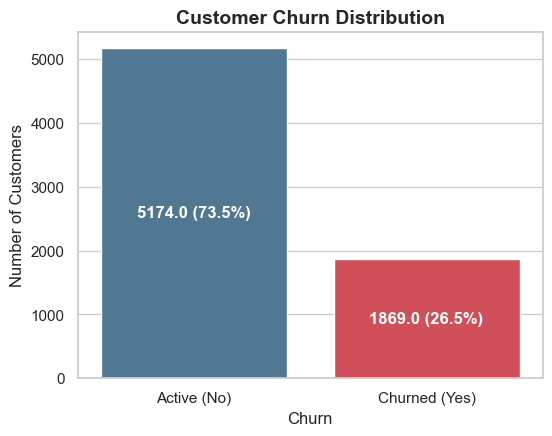

In [5]:
# Churn distribution countplot
plt.figure(figsize=(6, 4.5))
ax = sns.countplot(x='Churn', data=df_clean, palette=CHURN_PALETTE)
plt.title('Customer Churn Distribution', weight='bold')
plt.xticks([0, 1], ['Active (No)', 'Churned (Yes)'])
plt.ylabel('Number of Customers')

# Annotate percentage
total = len(df_clean)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height} ({height/total*100:.1f}%)',
                (p.get_x() + p.get_width() / 2., height / 2),
                ha='center', va='center', color='white', weight='bold')
plt.show()

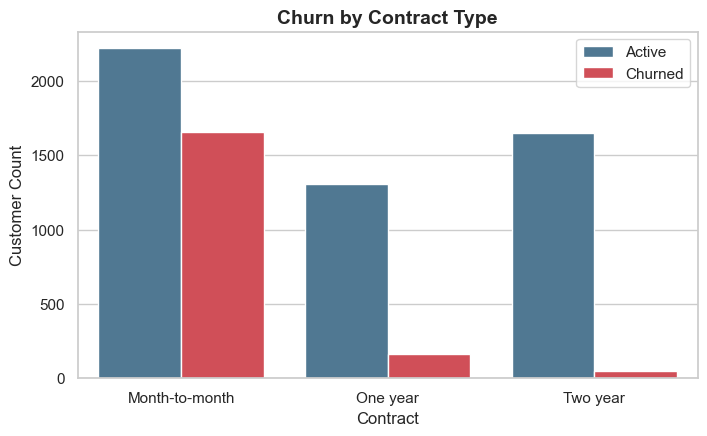

In [6]:
# Churn rate by Contract Type
plt.figure(figsize=(8, 4.5))
sns.countplot(x='Contract', hue='Churn', data=df_clean, palette=CHURN_PALETTE)
plt.title('Churn by Contract Type', weight='bold')
plt.legend(labels=['Active', 'Churned'])
plt.ylabel('Customer Count')
plt.show()

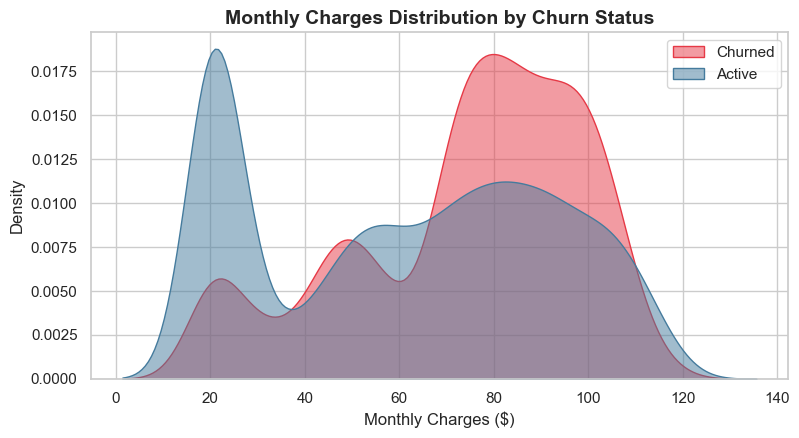

In [7]:
# Distribution of Monthly Charges by Churn Status
plt.figure(figsize=(9, 4.5))
sns.kdeplot(data=df_clean, x='MonthlyCharges', hue='Churn', fill=True, palette=CHURN_PALETTE, common_norm=False, alpha=0.5)
plt.title('Monthly Charges Distribution by Churn Status', weight='bold')
plt.xlabel('Monthly Charges ($)')
plt.legend(labels=['Churned', 'Active'])
plt.show()

C:\Users\Melwin\AppData\Local\Temp\ipykernel_21024\439410200.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df_clean, palette=CHURN_PALETTE)


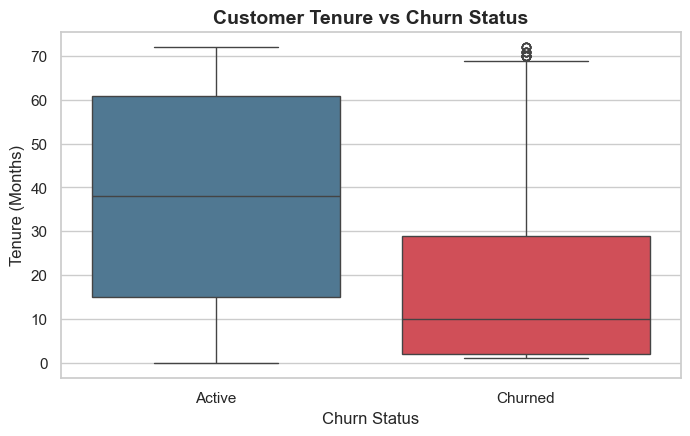

In [8]:
# Tenure boxplot vs Churn
plt.figure(figsize=(8, 4.5))
sns.boxplot(x='Churn', y='tenure', data=df_clean, palette=CHURN_PALETTE)
plt.title('Customer Tenure vs Churn Status', weight='bold')
plt.xticks([0, 1], ['Active', 'Churned'])
plt.xlabel('Churn Status')
plt.ylabel('Tenure (Months)')
plt.show()

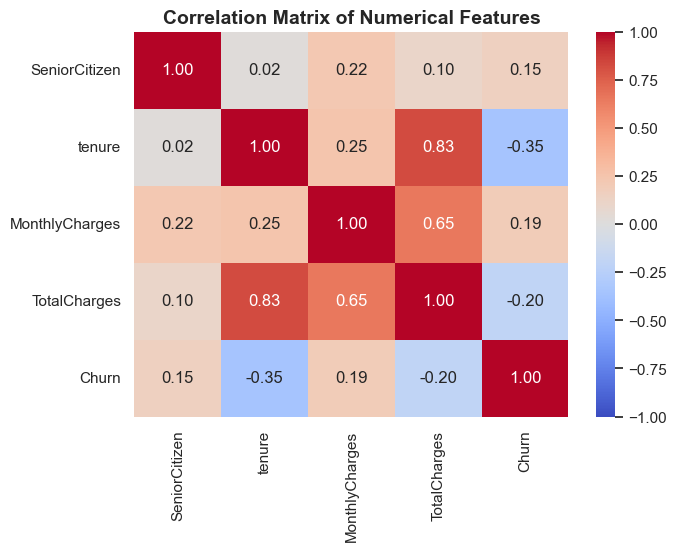

In [9]:
# Correlation heatmap for numerical features
plt.figure(figsize=(7, 5))
sns.heatmap(df_clean.select_dtypes(include=[np.number]).corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numerical Features', weight='bold')
plt.show()

## 4. Feature Engineering & Preprocessing

We use `preprocess_data()` to clean columns, bin `tenure` into ranges, and list numerical vs categorical splits. Then, we fetch the ColumnTransformer.

In [10]:
X, y, cat_cols, num_cols = preprocess_data(df_clean)
preprocessor = get_preprocessor(cat_cols, num_cols)
print(f"X Shape: {X.shape}")

Created feature 'TenureGroup' successfully.
Dropped 'customerID' column.
Numerical features to scale: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features to encode: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']
X Shape: (7043, 20)


## 5. Model Training & Evaluation

We perform an 80-20 train-test split, build the Pipelines (Preprocessor + Classifier) for three models, and evaluate them on test set metrics.

In [11]:
# Split the data
X_train, X_test, y_train, y_test = split_dataset(X, y)

# Train all 3 pipeline models
pipelines = train_models(X_train, y_train, preprocessor)

Dataset split: Train shape = (5634, 20), Test shape = (1409, 20)
Training models with GridSearchCV optimization...

Grid Search Tuning for Logistic Regression...
Fitting 5 folds for each of 8 candidates, totalling 40 fits


Best parameters for Logistic Regression: {'classifier__C': 0.01, 'classifier__class_weight': 'balanced'}
Best CV F1-Score: 0.6330
Logistic Regression pipeline optimized and trained successfully.

Grid Search Tuning for Decision Tree...
Fitting 5 folds for each of 12 candidates, totalling 60 fits


Best parameters for Decision Tree: {'classifier__max_depth': 6, 'classifier__min_samples_leaf': 8}
Best CV F1-Score: 0.5565
Decision Tree pipeline optimized and trained successfully.

Grid Search Tuning for Random Forest...
Fitting 5 folds for each of 54 candidates, totalling 270 fits


Best parameters for Random Forest: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 6, 'classifier__n_estimators': 100}
Best CV F1-Score: 0.6377
Random Forest pipeline optimized and trained successfully.


In [12]:
# Evaluate and collect metrics
eval_results = []
for name, model_pipeline in pipelines.items():
    metrics = evaluate_model(model_pipeline, X_test, y_test, name)
    eval_results.append(metrics)


Evaluating Model: Logistic Regression
Accuracy  : 0.7431
Precision : 0.5103
Recall    : 0.7914
F1 Score  : 0.6205

Classification Report:
              precision    recall  f1-score   support

      Active       0.91      0.73      0.81      1035
     Churned       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409

Confusion Matrix:
[[751 284]
 [ 78 296]]
Saved chart: C:\Users\Melwin\Work\Customer-Churn-Prediction-System\outputs\charts\confusion_matrix_logistic_regression.png

Evaluating Model: Decision Tree
Accuracy  : 0.8013
Precision : 0.6679
Recall    : 0.5000
F1 Score  : 0.5719

Classification Report:
              precision    recall  f1-score   support

      Active       0.83      0.91      0.87      1035
     Churned       0.67      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       

Saved chart: C:\Users\Melwin\Work\Customer-Churn-Prediction-System\outputs\charts\confusion_matrix_decision_tree.png

Evaluating Model: Random Forest
Accuracy  : 0.7622
Precision : 0.5364
Recall    : 0.7674
F1 Score  : 0.6315

Classification Report:
              precision    recall  f1-score   support

      Active       0.90      0.76      0.82      1035
     Churned       0.54      0.77      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409

Confusion Matrix:
[[787 248]
 [ 87 287]]
Saved chart: C:\Users\Melwin\Work\Customer-Churn-Prediction-System\outputs\charts\confusion_matrix_random_forest.png


## 6. Model Comparison & Conclusion

In [13]:
comparison_df, best_model = compare_models(eval_results)


Model Comparison Table:
              Model Accuracy Precision   Recall F1 Score
Logistic Regression 74.3080%  51.0345% 79.1444% 62.0545%
      Decision Tree 80.1278%  66.7857% 50.0000% 57.1865%
      Random Forest 76.2243%  53.6449% 76.7380% 63.1463%

Best Model Selected: Random Forest with F1-Score: 63.1463%


## 7. Strategic Business Insights Summary

Based on the analysis, here are the main insights and recommended actions:
1. **Contract Strategy**: Month-to-month contracts account for the highest churn volume. Migrating these customers to 1- or 2-year terms via loyalty incentives is crucial.
2. **Billing Strategy**: Electronic check users have much higher churn than auto-pay users. Offering incentives to register for auto-pay will reduce friction.
3. **Price Audits**: Churned customers have higher monthly charges. A service-value audit is recommended for high-bill customer cohorts.
4. **Onboarding focus**: The first 12 months is the peak risk window. Proactive onboarding support should be deployed during this period.